# 谱峭度

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["SimHei"]  # 指定默认字体
plt.rcParams["axes.unicode_minus"] = False  # 解决保存图像是负号'-'显示为方块的问题

import scipy
from scipy.fft import fft
from scipy.signal import stft
from scipy.stats import kurtosis


import xcw_package as xcw


## 0.读取数据

In [2]:
file_path="D:\那仁风电场偏航轴承数据/index.csv"
index=pd.read_csv(file_path,encoding="utf_8_sig")
index['采样频率'].value_counts()

采样频率
51200Hz    128
25600Hz     84
Name: count, dtype: int64

In [3]:
sample_rate="25600Hz"
fault_type="23#径向"
measure_point="测点5"   
database=index[(index['采样频率']==sample_rate)&(index['故障类型']==fault_type)&(index['测点']==measure_point)]
database

,设备,测点,采样频率,日期,故障类型,文件路径
44,那仁10K,测点5,25600Hz,2023-10-19 11:32:04,23#径向,D:\那仁风电场偏航轴承数据/时域波形数据\那仁10K_23#径向_T219e219575a...
45,那仁10K,测点5,25600Hz,2023-10-19 11:35:01,23#径向,D:\那仁风电场偏航轴承数据/时域波形数据\那仁10K_23#径向_T219e219575a...
46,那仁10K,测点5,25600Hz,2023-10-19 11:36:52,23#径向,D:\那仁风电场偏航轴承数据/时域波形数据\那仁10K_23#径向_T219e219575a...
47,那仁10K,测点5,25600Hz,2023-10-19 11:38:50,23#径向,D:\那仁风电场偏航轴承数据/时域波形数据\那仁10K_23#径向_T219e219575a...
48,那仁10K,测点5,25600Hz,2023-10-19 11:41:33,23#径向,D:\那仁风电场偏航轴承数据/时域波形数据\那仁10K_23#径向_T219e219575a...
49,那仁10K,测点5,25600Hz,2023-10-19 11:43:30,23#径向,D:\那仁风电场偏航轴承数据/时域波形数据\那仁10K_23#径向_T219e219575a...


信号长度: 1536000
采样频率: 51200.0 Hz
采样间隔: 0.000020 s
信号采样时长: 30.000 s
频谱频率分辨率: 0.033 Hz
可分析频率上限: 25600.0 Hz



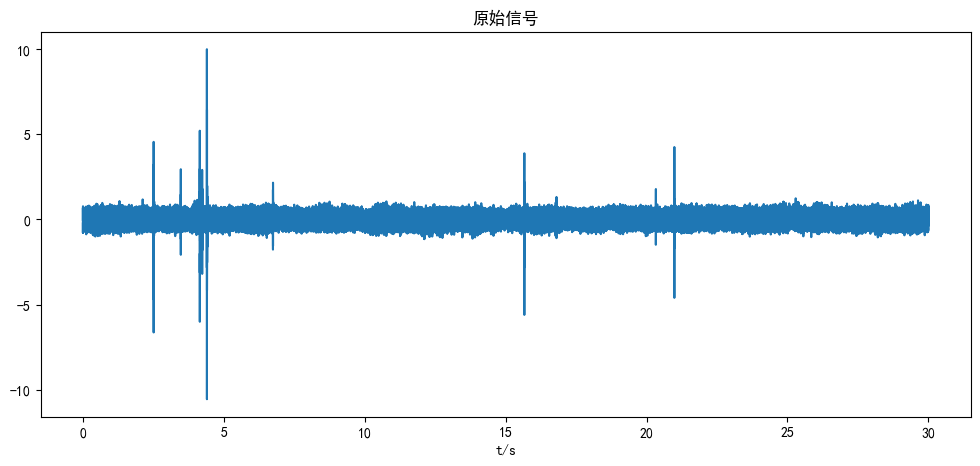

In [19]:
data=database.iloc[3]
data_path=data['文件路径']
# 读取文件
with open(data_path, 'r') as file:
    data_str = file.read()
    data_list = data_str.split(',')

# 将字符串数据转换为浮点数，并创建 NumPy 数组
data_array = np.array(data_list, dtype=float)
signal=xcw.Signal(data_array,1/51200)
signal.info()
signal.plot(title="原始信号")

### 0.1.降采样

信号长度: 25600
采样频率: 25600.0 Hz
采样间隔: 0.000039 s
信号采样时长: 1.000 s
频谱频率分辨率: 1.000 Hz
可分析频率上限: 12800.0 Hz



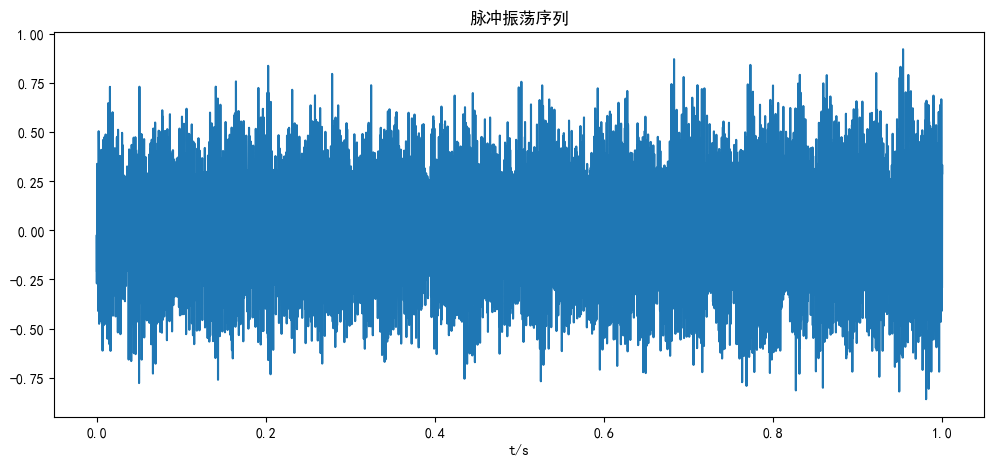

In [20]:
signal=xcw.resample(signal,25600,25600,5)
signal.info() 
signal.plot(title="脉冲振荡序列")

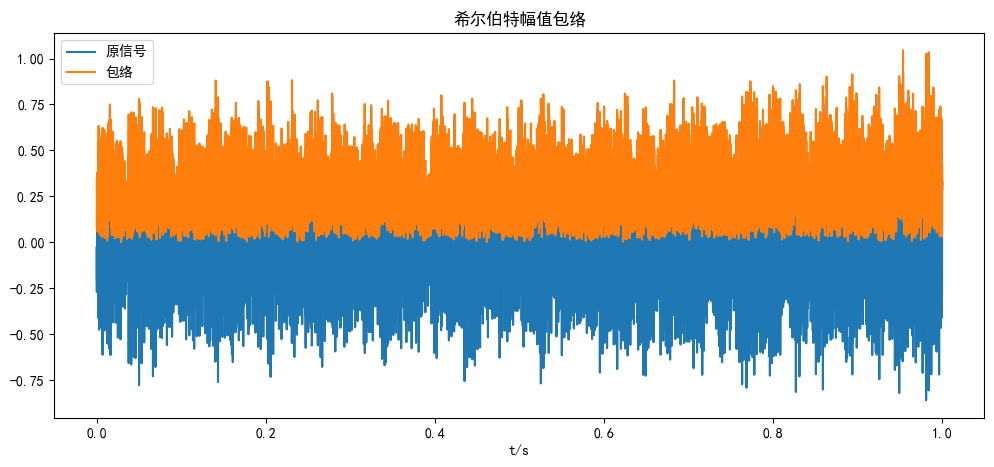

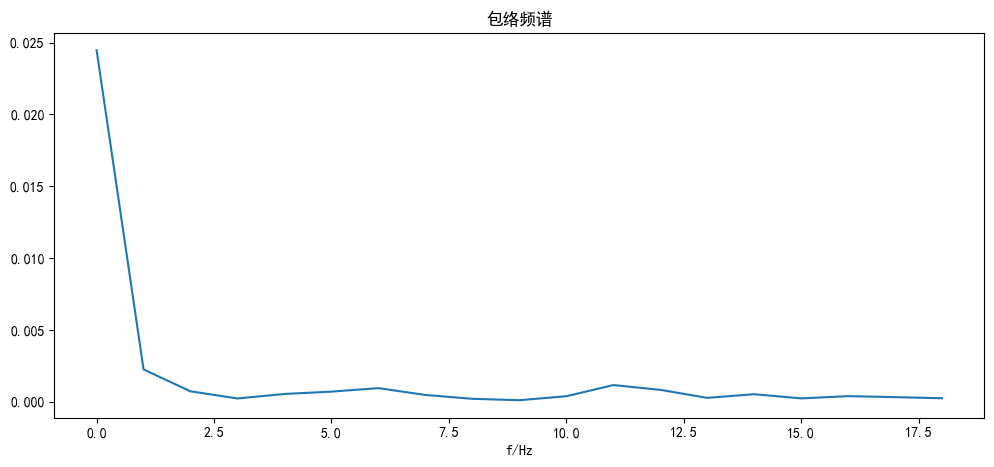

In [17]:
xcw.plot_Hilbertenvelope(signal,20)

## 1.故障检测

### 1.1.平均功率谱

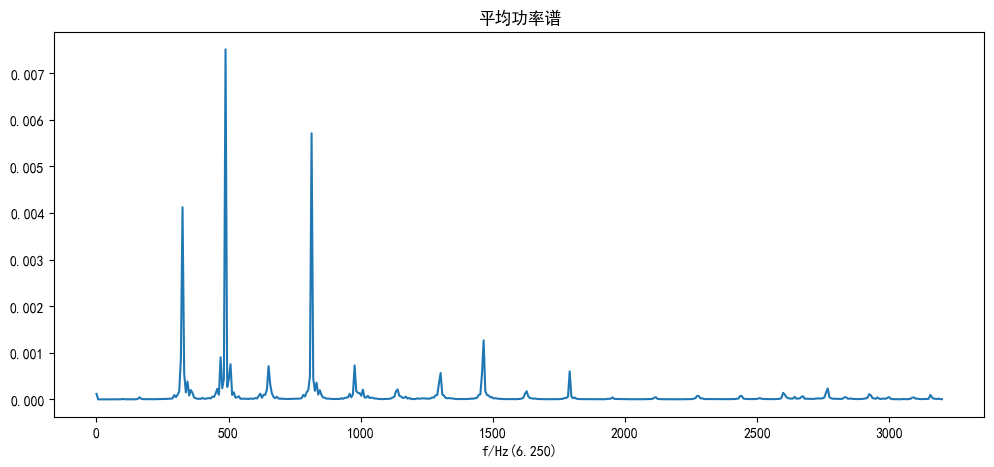

In [16]:
xcw.plot_powerspectrum(signal,1024)

### 1.2.STFT

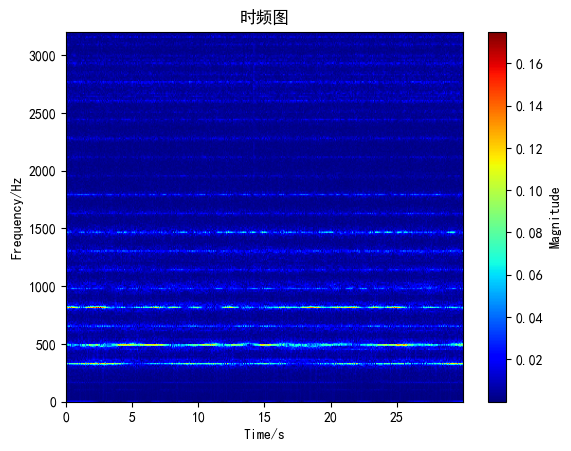

In [19]:
xcw.plot_stft(signal,512)

### 1.3.谱峭度

全局峭度

In [20]:
kurtosis(signal.data)

-0.023628451892985236

### 1.3.2.频谱峭度

In [21]:
def plot_spectralkurtosis(s,nperseg,title="谱峭度",result=False):
    f, t, fft_data = stft(
        s.data, fs=s.f_s, nperseg=nperseg
    )  # 计算STFT，得到矩阵fft_data
    fft_data=np.abs(fft_data) 
    sprectral_kurtosis = np.zeros(fft_data.shape[0])  
    for i in range(fft_data.shape[0]):
        sprectral_kurtosis[i] = kurtosis(fft_data[i,:])#计算每一行的峭度
    plt.figure(figsize=(12,5))
    plt.plot(f, sprectral_kurtosis)
    plt.title(title)
    plt.xlabel("f/Hz")
    plt.show()
    if result:
        return sprectral_kurtosis
    else:
        return None

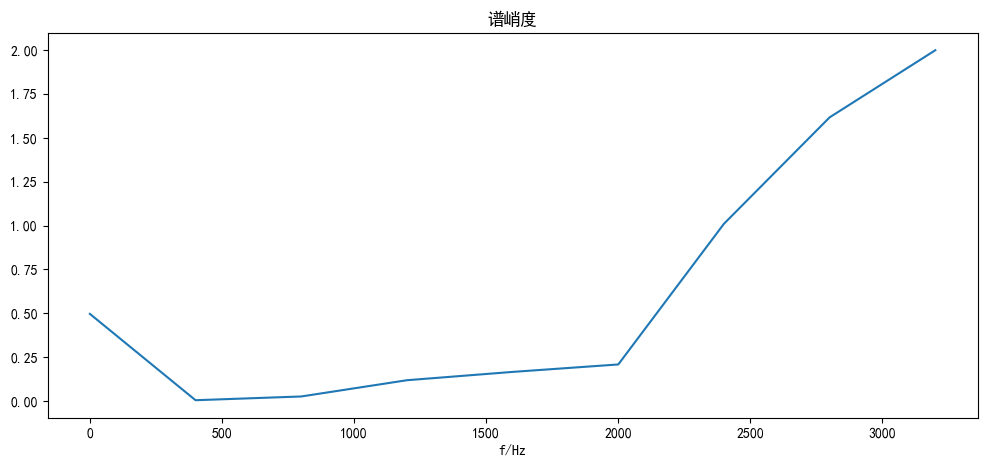

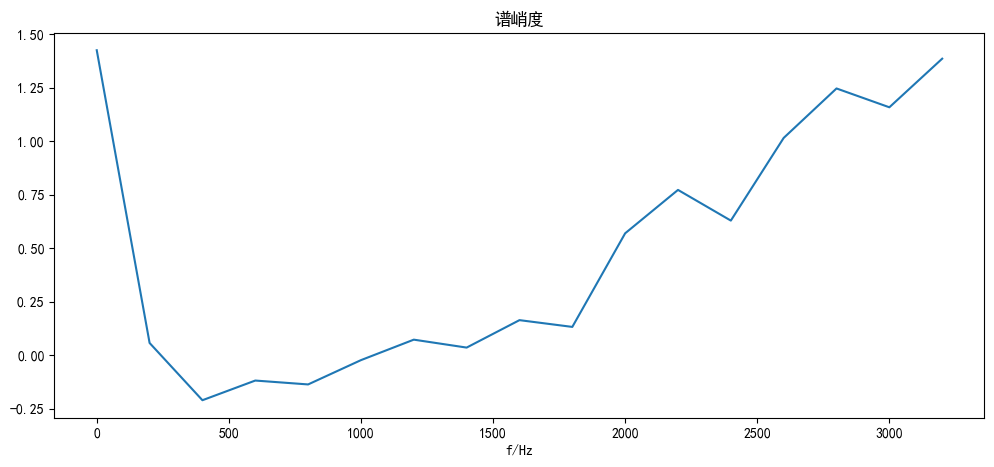

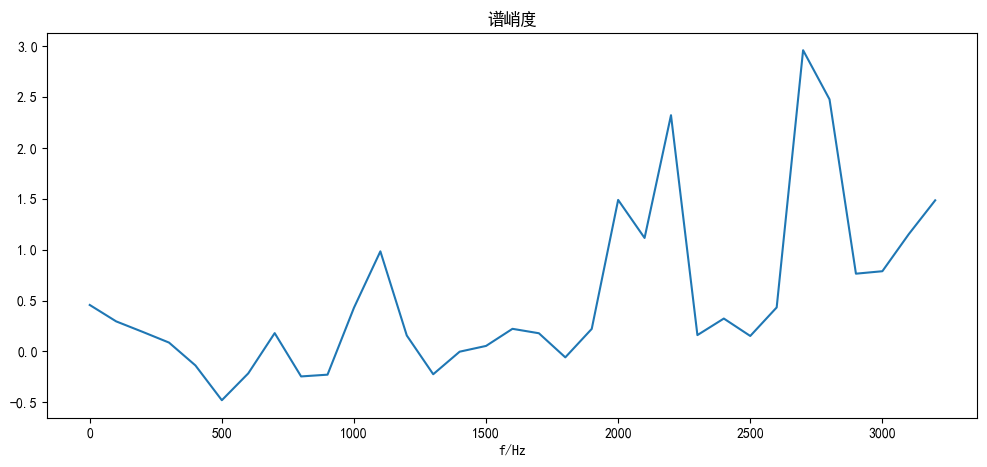

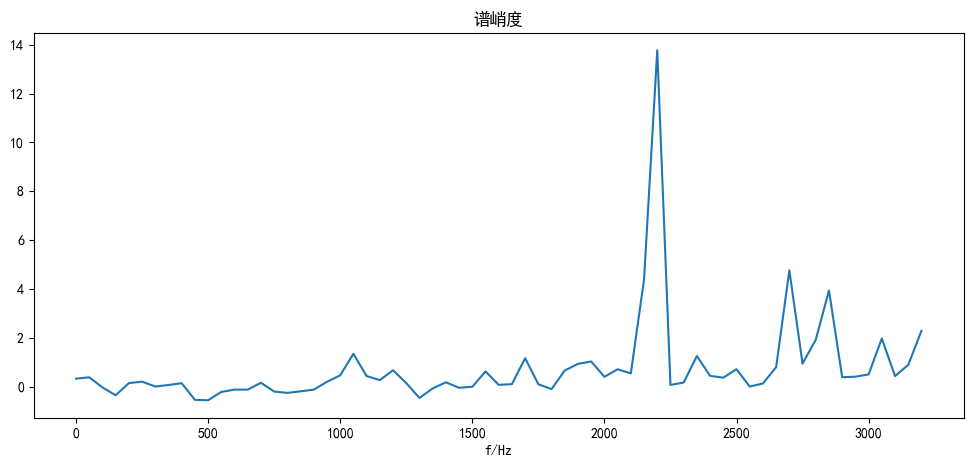

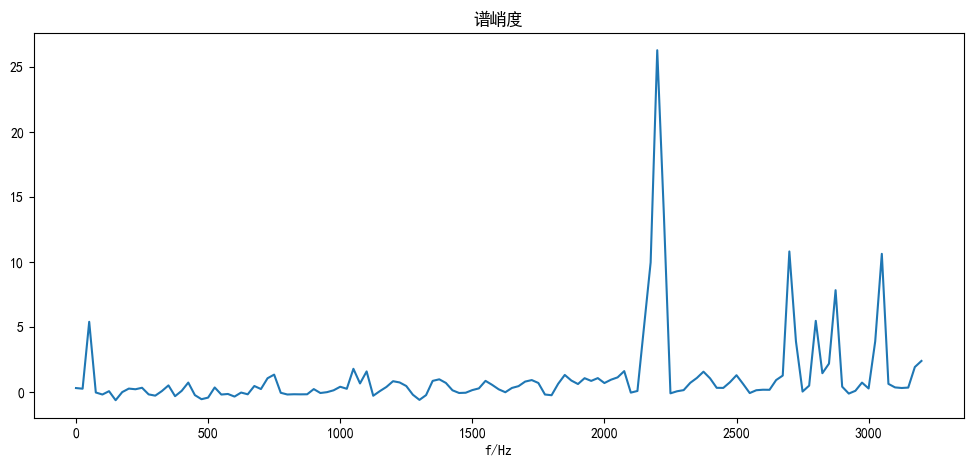

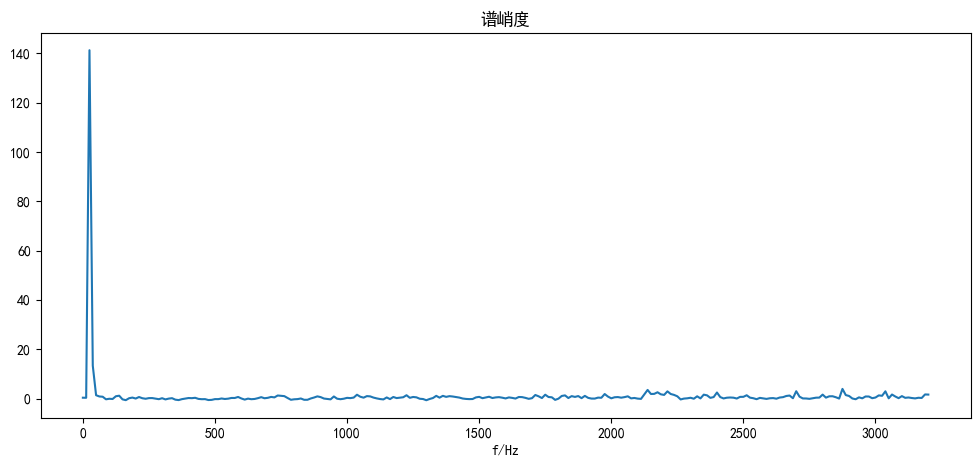

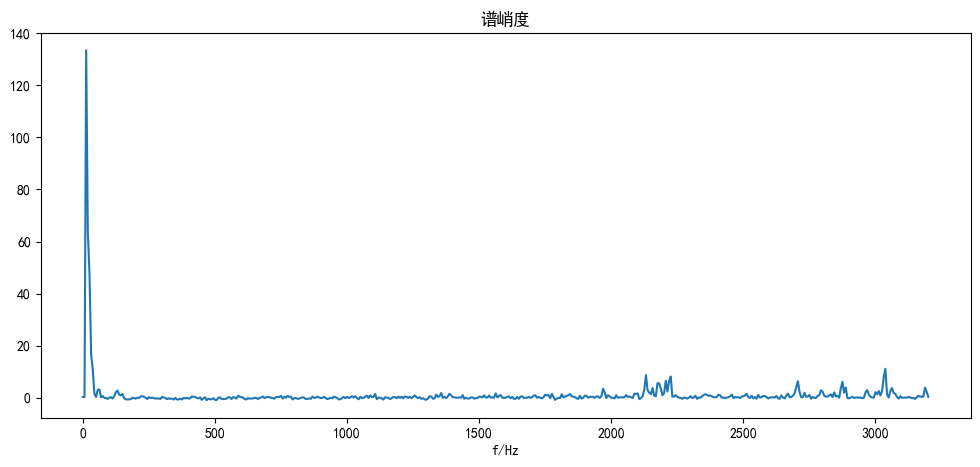

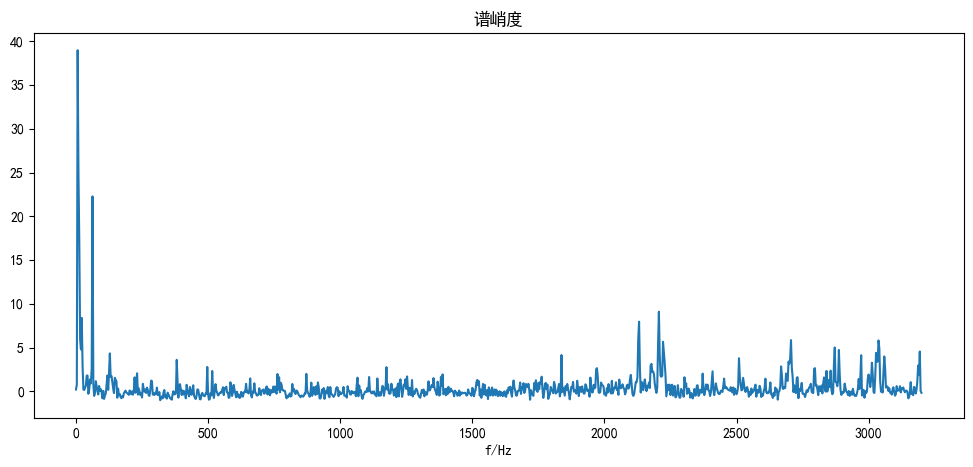

In [26]:
result=np.zeros((8,2))
for i,N_w in enumerate([16,32,64,128,256,512,1024,2048]):
    res=plot_spectralkurtosis(signal,N_w,result=True)
    max=res.max()
    index=res.argmax()*signal.f_s/N_w
    result[i]=(max,index)